# Performance Analytics

## Step 1: Daily Return Calculation

In this section, we calculate the daily returns for all 40 mutual fund schemes using their historical NAV values.

Formula:

Daily Return = (Today's NAV / Previous Day's NAV) - 1

In [1032]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress


plt.style.use("ggplot")
%matplotlib inline

In [1033]:
df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

In [1034]:
df["date"] = pd.to_datetime(df["date"])

In [1035]:
df = df.sort_values(['amfi_code', 'date', 'nav'])

In [1036]:
df["prev_nav"] = (df.groupby("amfi_code")["nav"].shift(1))

In [1037]:
df["daily_return"] = (df["nav"] / df["prev_nav"]) - 1

In [1038]:
df[["amfi_code", "date", "nav", "daily_return"]].head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [1039]:
df["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

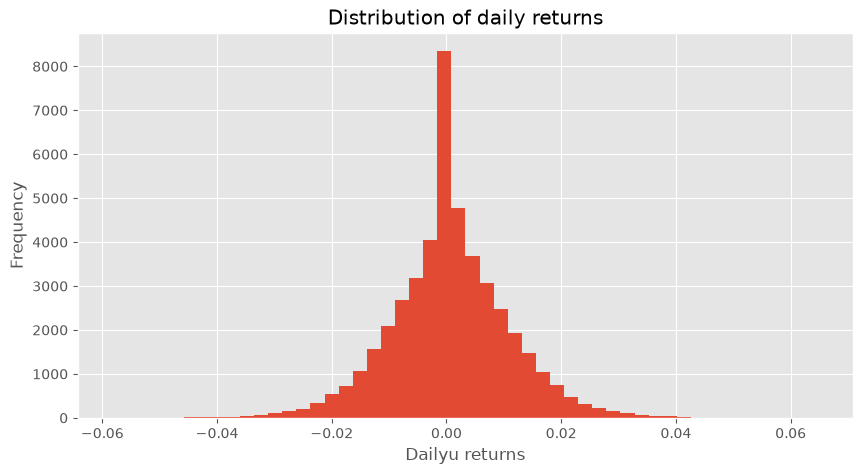

In [1040]:
plt.figure(figsize=(10,5))
plt.hist(df["daily_return"].dropna(),bins=50)
plt.title("Distribution of daily returns")
plt.xlabel("Dailyu returns")
plt.ylabel("Frequency")
plt.show()

In [1041]:
df["daily_return"].sort_values().head(10)

12774   -0.058102
4917    -0.051847
12952   -0.050335
45312   -0.048870
5560    -0.048634
19804   -0.048367
13333   -0.048305
20307   -0.046524
26048   -0.045429
38520   -0.045218
Name: daily_return, dtype: float64

In [1042]:
df["daily_return"].sort_values(ascending=False).head(10)

24745    0.064713
13226    0.059304
5207     0.054851
25566    0.053320
25832    0.051811
24155    0.051113
24371    0.049051
45082    0.048490
24356    0.048454
25091    0.047123
Name: daily_return, dtype: float64

In [1043]:
df.to_csv("../data/processed/daily_returns.csv",index=False)

## Step 2: CAGR Calculations

Compound Annual Growth Rate (CAGR) measure the annualized return of a mutual over a specialized period. 
We caculate the CGAR for 1year. 3 year and 5 year periods for all 40 schemes.

In [1044]:
print("Start Date : ",df["date"].min())
print("End Date : ",df["date"].max())

Start Date :  2022-01-03 00:00:00
End Date :  2026-05-29 00:00:00


In [1045]:
(df["date"].max()- df["date"].min()).days

1607

In [1046]:
latest_nav = (df[df["date"] == latest_date][["amfi_code", "nav"]].rename(columns={"nav": "latest_nav"}))
latest_nav.head()

,amfi_code,latest_nav
1149,100016,583.6113
2299,100025,31.8843
3449,100033,342.0072
4599,101206,773.2939
5749,101207,53.9836


In [1047]:
latest_date = df["date"].max()
latest_date

Timestamp('2026-05-29 00:00:00')

In [1048]:
from pandas import DateOffset

one_year_date = latest_date - DateOffset(years=1)
three_year_date = latest_date - DateOffset(years=3)
five_year_date = latest_date - DateOffset(years=5)

print("1 year date: ",one_year_date)
print("3 year date: ",three_year_date)
print("5 year date: ",five_year_date)

1 year date:  2025-05-29 00:00:00
3 year date:  2023-05-29 00:00:00
5 year date:  2021-05-29 00:00:00


In [1049]:
one_year_nav = (df[df["date"] == one_year_date][["amfi_code", "nav"]].rename(columns={"nav": "nav_1y"}))
one_year_nav.head()

,amfi_code,nav_1y
888,100016,596.8877
2038,100025,30.7452
3188,100033,223.1951
4338,101206,522.7639
5488,101207,71.0180


In [1050]:
three_year_nav = (df[df["date"] == three_year_date][["amfi_code", "nav"]].rename(columns={"nav": "nav_3y"}))
three_year_nav.head()

,amfi_code,nav_3y
365,100016,561.5519
1515,100025,28.4135
2665,100033,147.2155
3815,101206,360.4971
4965,101207,61.3081


## Merging NAV data for CAGR calculations

In [1051]:
cagr_df = latest_nav.merge(one_year_nav, on="amfi_code", how="left")
cagr_df = cagr_df.merge(three_year_nav, on="amfi_code", how="left")
cagr_df.head()

,amfi_code,latest_nav,nav_1y,nav_3y
0,100016,583.6113,596.8877,561.5519
1,100025,31.8843,30.7452,28.4135
2,100033,342.0072,223.1951,147.2155
3,101206,773.2939,522.7639,360.4971
4,101207,53.9836,71.0180,61.3081


## Calculating 1-year and 3-year CAGR


In [1052]:
cagr_df["cagr_1y"] = ((cagr_df["latest_nav"]/ cagr_df["nav_1y"])**(1/1))-1
cagr_df["cagr_3y"] = ((cagr_df["latest_nav"]/ cagr_df["nav_1y"])**(1/3))-1



In [1053]:
cagr_df["cagr_1y"] = cagr_df["cagr_1y"] * 100
cagr_df["cagr_3y"] = cagr_df["cagr_3y"] * 100

In [1054]:
cagr_df = cagr_df.round({"cagr_1y": 2,"cagr_3y":2})
cagr_df.head()

,amfi_code,latest_nav,nav_1y,nav_3y,cagr_1y,cagr_3y
0,100016,583.6113,596.8877,561.5519,-2.22,-0.75
1,100025,31.8843,30.7452,28.4135,3.70,1.22
2,100033,342.0072,223.1951,147.2155,53.23,15.29
3,101206,773.2939,522.7639,360.4971,47.92,13.94
4,101207,53.9836,71.0180,61.3081,-23.99,-8.74


In [1055]:
cagr_df.to_csv("../data/processed/cagr_comparison.csv",index=False)

## Step 3: Sharpe Ratio

The Sharpe Ratio measures the risk-adjusted return of a mutual fund. It compares the excess return over the risk-free rate with the total volatility of returns.

Formula:


Where:
- Rp = Average Daily Return
- Rf = 6.5% (Annual Risk-Free Rate)
- √252 = Annualization Factor

In [1056]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252
print("Annual risk free rate: ",risk_free_rate)
print("Daily risk free rate: ",daily_rf)

Annual risk free rate:  0.065
Daily risk free rate:  0.00025793650793650796


In [1057]:
sharpe_df = df.groupby("amfi_code").agg(avg_return=("daily_return", "mean"), std_return=("daily_return", "std")).reset_index()
sharpe_df.head()

,amfi_code,avg_return,std_return
0,100016,0.000142,0.009164
1,100025,0.000170,0.002460
2,100033,0.001080,0.011929
3,101206,0.000852,0.009177
4,101207,0.000424,0.016251


In [1058]:
sharpe_df["sharpe_ratio"] = ((sharpe_df["avg_return"] - daily_rf)/sharpe_df["std_return"])*np.sqrt(252)

In [1059]:
sharpe_df = sharpe_df.round({"avg_return": 6,"std_return": 6,"sharpe_ratio": 2})

In [1060]:
sharpe_df["sharpe_rank"] = (sharpe_df["sharpe_ratio"].rank(ascending=False, method="dense").astype(int))

# Step 4: Sortino Ratio

The Sortino Ratio measures the risk-adjusted return by considering only downside volatility (negative return days).

Formula:

Sortino Ratio = (Rp - Rf) / Downside Standard Deviation × √252

Where:
- Rp = Average Daily Return
- Rf = Daily Risk-Free Rate
- Downside Deviation = Standard deviation of negative daily returns

In [1061]:
sortino_df = (df[df["daily_return"] < 0].groupby("amfi_code").agg(downside_std=("daily_return", "std")).reset_index())
sortino_df.head()

,amfi_code,downside_std
0,100016,0.005261
1,100025,0.001481
2,100033,0.007133
3,101206,0.005238
4,101207,0.009555


In [1062]:
sortino_df = sortino_df.merge(sharpe_df[["amfi_code", "avg_return"]],on="amfi_code",how="left")
sortino_df.head()

,amfi_code,downside_std,avg_return
0,100016,0.005261,0.000142
1,100025,0.001481,0.000170
2,100033,0.007133,0.001080
3,101206,0.005238,0.000852
4,101207,0.009555,0.000424


In [1063]:
sortino_df["sortino_ratio"] = ((sortino_df["avg_return"] - daily_rf)/ sortino_df["downside_std"]) * np.sqrt(252)

In [1064]:
sortino_df["sortino_rank"] = (sortino_df["sortino_ratio"].rank(ascending=False, method="dense").astype(int))

In [1065]:
sortino_df = sortino_df.round({ "avg_return": 6,"downside_std": 6,"sortino_ratio": 2})

In [1066]:
sortino_df.to_csv( "../data/processed/sortino_ratio.csv",index=False)

## Step 5: Alpha and Beta

Alpha and Beta are calculated by comparing mutual fund daily returns with benchmark daily returns using linear regression.

Formula:

Fund Return = Alpha + Beta × Benchmark Return

In [1067]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


### Exploring Benchmark Data

In [1068]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [1069]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [1070]:
nifty100["date"] = pd.to_datetime(nifty100["date"])
nifty100 = nifty100.sort_values("date")
nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [1071]:
nifty100["benchmark_return"] = (nifty100["close_value"].pct_change())
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


### Merging Fund Returns with Benchmark returns

In [1072]:
benchmark_returns = nifty100[["date", "benchmark_return"]]
benchmark_returns.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [1073]:
merged_df = df.merge(benchmark_returns, on="date",how="inner")
merged_df.head()

,amfi_code,date,nav,prev_nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,520.4608,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,515.0971,0.012865,0.004003
3,100016,2022-01-06,515.7880,521.7239,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,515.7880,-0.001210,0.006150


### Calculating Alpha and beta using Linear Regression

In [1074]:
alpha_beta = []

for fund in merged_df["amfi_code"].unique():
    fund_data =  merged_df[merged_df["amfi_code"] == fund].dropna(subset=["daily_return","benchmark_return"])
    slope, intercept, r_value, p_value, std_err = linregress(
        fund_data["benchmark_return"],
        fund_data["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": fund,
        "alpha": intercept * 252,
        "beta": slope
    })

alpha_beta_df = pd.DataFrame(alpha_beta)


In [1075]:
alpha_beta_df = alpha_beta_df.round({
    "alpha": 4,
    "beta": 4
})

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.0375,-0.0583
1,100025,0.0428,0.0012
2,100033,0.2720,0.0051
3,101206,0.2140,0.0211
4,101207,0.1090,-0.0653


In [1076]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

# Step 6: Maximum Drawdown

Maximum Drawdown measures the largest decline from a fund's historical peak NAV.

Formula:

Drawdown = (NAV / Running Maximum NAV) - 1

In [1077]:
df["running_max"] = (df.groupby("amfi_code")["nav"].cummax())
df.head()

,amfi_code,date,nav,prev_nav,daily_return,running_max
0,100016,2022-01-03,520.4608,NaN,NaN,520.4608
1,100016,2022-01-04,515.0971,520.4608,-0.010306,520.4608
2,100016,2022-01-05,521.7239,515.0971,0.012865,521.7239
3,100016,2022-01-06,515.7880,521.7239,-0.011377,521.7239
4,100016,2022-01-07,515.1639,515.7880,-0.001210,521.7239


In [1078]:
df["drawdown"] = (df["nav"] / df["running_max"]) - 1
df.head()

,amfi_code,date,nav,prev_nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,520.4608,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,515.0971,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,521.7239,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,515.7880,-0.001210,521.7239,-0.012574


In [1079]:
worst_dd = (
    df.loc[
        df.groupby("amfi_code")["drawdown"].idxmin()
    ][["amfi_code", "date", "drawdown"]]
)

worst_dd.columns = [
    "amfi_code",
    "worst_drawdown_date",
    "max_drawdown"
]

In [1080]:
max_dd_df = worst_dd.copy()

max_dd_df["max_drawdown"] = (
    max_dd_df["max_drawdown"] * 100
).round(2)

max_dd_df = max_dd_df.reset_index(drop=True)

In [1081]:
max_dd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

# Step 7: Fund Scorecard

The fund scorecard combines multiple performance metrics into a single score out of 100.

In [1082]:
score_df = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

score_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [1083]:
score_df["return_rank"] = score_df["return_3yr_pct"].rank(
    ascending=False,
    method="dense"
)

score_df["sharpe_rank"] = score_df["sharpe_ratio"].rank(
    ascending=False,
    method="dense"
)

score_df["alpha_rank"] = score_df["alpha"].rank(
    ascending=False,
    method="dense"
)

score_df["expense_rank"] = score_df["expense_ratio_pct"].rank(
    ascending=True,
    method="dense"
)

score_df["drawdown_rank"] = score_df["max_drawdown_pct"].rank(
    ascending=False,
    method="dense"
)

In [1084]:
score_df["fund_score"] = (
    (41 - score_df["return_rank"]) * 0.30 +
    (41 - score_df["sharpe_rank"]) * 0.25 +
    (41 - score_df["alpha_rank"]) * 0.20 +
    (41 - score_df["expense_rank"]) * 0.15 +
    (41 - score_df["drawdown_rank"]) * 0.10
)

In [1085]:
score_df["fund_score"] = (
    score_df["fund_score"] / score_df["fund_score"].max()
) * 100

score_df["fund_score"] = score_df["fund_score"].round(2)

In [1086]:
score_df["overall_rank"] = (
    score_df["fund_score"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

In [1087]:
score_df.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)


# Step 8: Tracking Error

Tracking Error measures how closely a fund follows its benchmark.

Formula:

Tracking Error = std(Fund Return − Benchmark Return) × √252

In [1088]:
merged_df["tracking_diff"] = (merged_df["daily_return"]- merged_df["benchmark_return"])
merged_df.head()

,amfi_code,date,nav,prev_nav,daily_return,benchmark_return,tracking_diff
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,520.4608,-0.010306,-0.013540,0.003234
2,100016,2022-01-05,521.7239,515.0971,0.012865,0.004003,0.008862
3,100016,2022-01-06,515.7880,521.7239,-0.011377,-0.002935,-0.008442
4,100016,2022-01-07,515.1639,515.7880,-0.001210,0.006150,-0.007360


In [1089]:
tracking_df = (merged_df.groupby("amfi_code").agg(tracking_error=("tracking_diff",lambda x: x.std() * np.sqrt(252))).reset_index())
tracking_df.head()

,amfi_code,tracking_error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [1090]:
tracking_df["tracking_error"] = (tracking_df["tracking_error"].round(4))
tracking_df.head()

,amfi_code,tracking_error
0,100016,0.1993
1,100025,0.1345
2,100033,0.2287
3,101206,0.1927
4,101207,0.2921


In [1091]:
tracking_df.to_csv("../data/processed/tracking_error.csv",index=False)

# Benchmark Comparison Chart

Comparing the Top 5 Ranked Funds with NIFTY50 and NIFTY100 over the last 3 years.

In [1092]:
top5 = score_df.sort_values("overall_rank").head(5)

In [1093]:
top5

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score,overall_rank
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,1.43,5,Very High,1.0,13.0,18.0,18.0,8.0,100.00,1
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,1.45,5,Moderately High,11.0,10.0,3.0,19.0,20.0,98.02,2
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,1.56,4,High,7.0,11.0,2.0,26.0,24.0,97.03,3
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.72,4,Very High,2.0,14.0,20.0,5.0,29.0,96.38,4
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,1.53,5,Very High,3.0,17.0,4.0,23.0,26.0,95.55,5


In [1094]:
top5_codes = top5["amfi_code"].tolist()

top5_codes

[119598, 120843, 120842, 119599, 101207]

In [1095]:
top5_nav = df[df["amfi_code"].isin(top5_codes)].copy()

In [1096]:
from pandas import DateOffset

start_date = df["date"].max() - DateOffset(years=3)

top5_nav = top5_nav[top5_nav["date"] >= start_date]

In [1097]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [1098]:
benchmark_plot = benchmark[
    benchmark["date"] >= start_date
].copy()

In [1099]:
nifty50 = benchmark_plot[
    benchmark_plot["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark_plot[
    benchmark_plot["index_name"] == "NIFTY100"
].copy()

In [1100]:
nifty50["normalized"] = (
    nifty50["close_value"] / nifty50["close_value"].iloc[0]
) * 100

nifty100["normalized"] = (
    nifty100["close_value"] / nifty100["close_value"].iloc[0]
) * 100

In [1101]:
top5_nav["normalized"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: (x / x.iloc[0]) * 100)
)

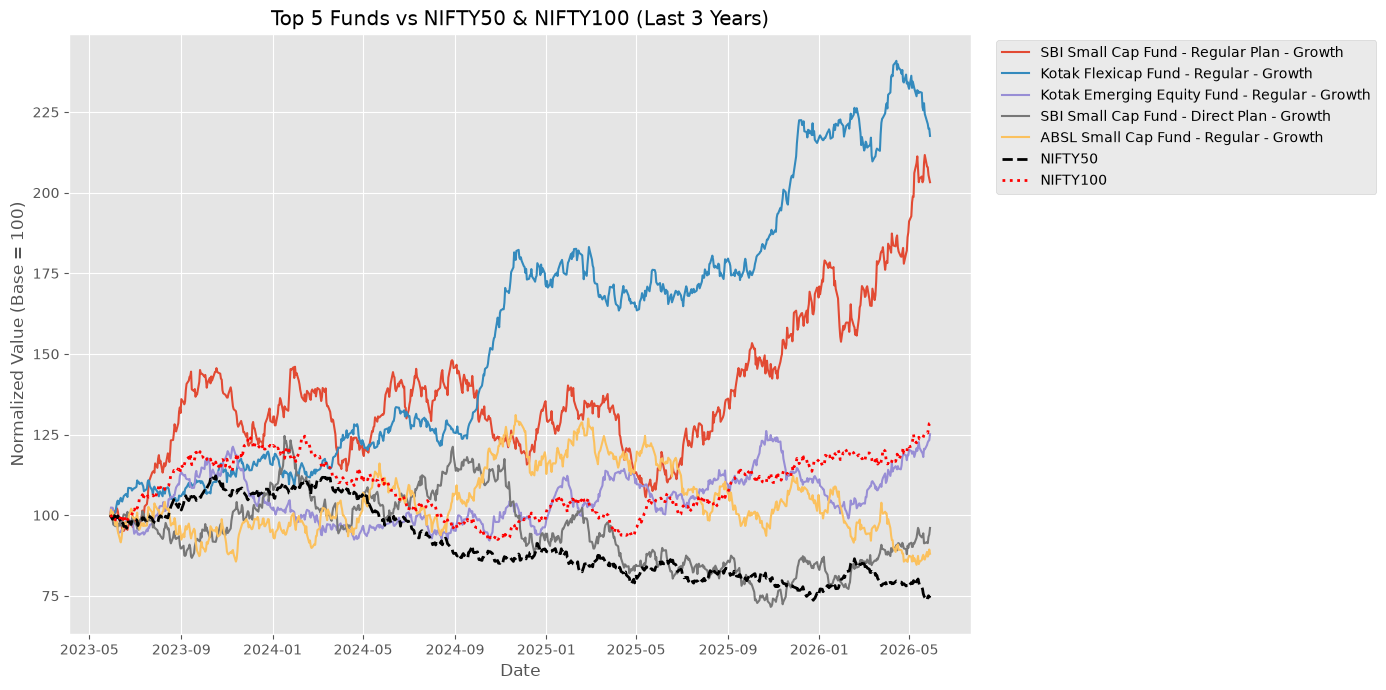

In [1102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

# Top 5 Funds
for code in top5_codes:
    temp = top5_nav[top5_nav["amfi_code"] == code]

    scheme = top5.loc[
        top5["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        temp["date"],
        temp["normalized"],
        label=scheme
    )

# NIFTY50
plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    color="black",
    linewidth=2,
    linestyle="--",
    label="NIFTY50"
)

# NIFTY100
plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    color="red",
    linewidth=2,
    linestyle=":",
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(True)

plt.tight_layout()
plt.savefig(
    "../data/processed/benchmark_comparison_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()